In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
from sklearn.neighbors import KernelDensity
from tqdm.auto import tqdm

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [3]:
RADIUS = 0.5
def sample_data(n, rng=None):
    centers = 2 * torch.rand(n, 2, generator=rng) - 1

    r = torch.sqrt(torch.rand(n, 1, generator=rng)) * RADIUS
    theta = torch.rand(n, 1, generator=rng) * 2 * torch.pi
    offsets = torch.hstack([r * torch.cos(theta), r * torch.sin(theta)])

    points = centers + offsets
    
    return points.to(device), centers.to(device)

In [299]:
def energy(x, y, sigma=0.1):
    d = torch.norm(x - y, dim=-1)
    # return torch.nn.functional.softplus(d - RADIUS, beta=1/sigma)
    return torch.nn.functional.relu(d - RADIUS)
    # return d

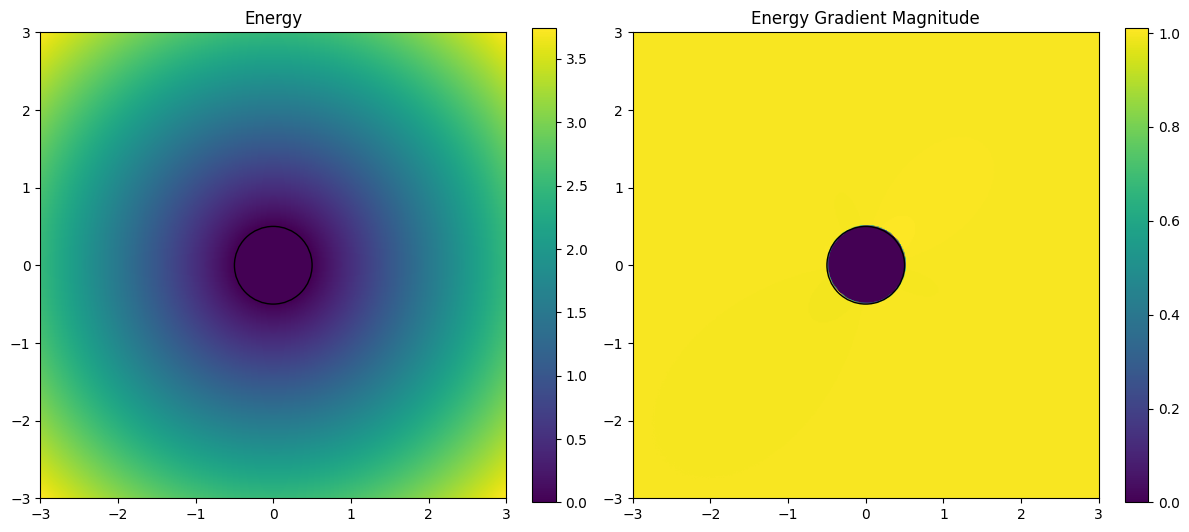

In [300]:
extent = 3
x = torch.linspace(-extent, extent, 400)
y = torch.linspace(-extent, extent, 400)
X, Y = torch.meshgrid(x, y, indexing="xy")
Z = energy(torch.stack([X.flatten(), Y.flatten()], dim=1), torch.zeros(1, 2)).reshape(X.shape).cpu()

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

for ax in axs:
    ax.add_patch(Circle((0, 0), radius=RADIUS, facecolor="none", edgecolor="black"))
    ax.grid(False)

grad = torch.sqrt(Z.diff(dim=0)[:, :-1]**2 + Z.diff(dim=1)[:-1, :]**2) / x.diff()[0]
im_0 = axs[0].imshow(Z, extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')
im_1 = axs[1].imshow(grad, extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')

axs[0].set_title("Energy")
axs[1].set_title("Energy Gradient Magnitude")

_ = fig.colorbar(im_0, ax=axs[0], fraction=0.046)
_ = fig.colorbar(im_1, ax=axs[1], fraction=0.046)

plt.savefig("figures/energy.pdf", bbox_inches="tight")

In [6]:
class MLP(nn.Module):
    def __init__(self, T):
        super().__init__()
        self.T = T
        self.net = nn.Sequential(
            nn.Linear(5, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, y, t):
        t = t.float() / self.T
        t = t.unsqueeze(1)
        inp = torch.cat([x, y, t], dim=1)
        return self.net(inp)

In [72]:
def train(config):
    torch.manual_seed(0)

    epochs = config["epochs"]
    batch_size = config["batch_size"]
    T = config["T"]
    betas = config["betas"]
    alphas = config["alphas"]
    alphas_cumprod = config["alphas_cumprod"]
    lambda_t = config["lambda_t"]

    model = MLP(T=T).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    
    for step in range(epochs):
        x0, y = sample_data(batch_size)
        t = torch.randint(0, T, (x0.size(0),), device=device)

        alpha_bar = alphas_cumprod[t, None]
        sigma_t = torch.sqrt(1 - alpha_bar)

        noise = torch.randn_like(x0)
        xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise
        xt.requires_grad_(True)
        
        pred = model(xt, y, t)

        x0_hat = (xt - sigma_t * pred.detach()) / torch.sqrt(alpha_bar)

        E = energy(x0_hat, y)
        grad_E = torch.autograd.grad(E.sum(), xt)[0].detach()
        target = noise + lambda_t[t].reshape(-1, 1) * sigma_t * grad_E

        loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

    return model

In [73]:
def sample(config, model, y, rng=None):
    model.eval()

    mode = config["mode"]
    T = config["T"]
    betas = config["betas"]
    alphas = config["alphas"]
    alphas_cumprod = config["alphas_cumprod"]
    lambda_t = config["lambda_t"]
    
    if rng is None:
        rng = torch.Generator()
        rng.manual_seed(0)

    y = y.reshape(-1, 2).to(device)
    n, _ = y.shape
    x = torch.randn(n, 2, generator=rng).to(device)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        with torch.no_grad():
            pred = model(x, y, t_batch)

        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]

        score = -pred / torch.sqrt(1 - alpha_bar)

        if mode == "sampling_guidance":
            sigma_t = torch.sqrt(1 - alpha_bar)
            x = x.clone().detach().requires_grad_(True)
            x0_hat = (x - sigma_t * pred) / torch.sqrt(alpha_bar)
            E = energy(x0_hat, y)
            grad_E = torch.autograd.grad(E.sum(), x)[0].detach()

            score = score - lambda_t[t] * grad_E

        noise = torch.randn(x.shape, generator=rng).to(device) if t > 0 else 0

        x = 1 / torch.sqrt(alpha) * (x + (1 - alpha) * score) + torch.sqrt(betas[t]) * noise
        x = x.detach()

    return x

In [9]:
def fraction_outside(x0, y):
    y = y.reshape(-1, 2)
    d = torch.norm(x0 - y, dim=1)

    return torch.mean((d > RADIUS).to(torch.float32))

In [10]:
def estimate_KL(kde):
    n = 100
    dx = 1/n
    p = 1 / (torch.pi * RADIUS**2)

    Z = np.dstack(
        np.meshgrid(
            np.linspace(-0.5, 0.5, n), 
            np.linspace(-0.5, 0.5, n)
        )
    ).reshape(-1, 2)

    r_mask = np.linalg.norm(Z, axis=1) < RADIUS
    Z = Z[r_mask]

    log_q = kde.score_samples(Z)

    return p * (np.log(p) - log_q).sum() * dx * dx

# Guidance Strength

$$
\epsilon_{target} = \epsilon + \sqrt{1 - \bar{\alpha}_t}\ \lambda \nabla_{x_t} E(\hat{x}_0)
$$

- Vary $\lambda$ and investigate KL divergence and fraction outside

In [301]:
def run_lambda_experiment():
    T = 100
    betas = torch.linspace(1e-4, 0.02, T).to(device)
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    lambdas = torch.linspace(0.0, 5.0, 11).to(device)

    rng = torch.Generator()
    rng.manual_seed(0)

    base_config = {
        "epochs": 20_000,
        "batch_size": 512,
        "T": T,
        "alphas": alphas,
        "alphas_cumprod": alphas_cumprod,
        "betas": betas,
        "lambda_t": None
    }

    runs = []  
    
    for lam in tqdm(lambdas):
        lambda_t = torch.full((T,), lam).to(device)

        config = {**base_config, "lambda_t": lambda_t}
        model = train(config)
        runs.append({"model": model, "config": config})

    return runs

In [302]:
runs_training = run_lambda_experiment()

  0%|          | 0/11 [00:00<?, ?it/s]

In [303]:
n_samples = 10_000

rng = torch.Generator()
rng.manual_seed(0)
y = 2 * torch.rand((n_samples, 2), generator=rng).to(device) - 1

kernel="tophat"
bandwidth="scott"

for run in runs_training:
    config = run["config"]
    model = run["model"]

    samples = sample({**config, "mode": "baseline"}, model, y)

    f_out = fraction_outside(samples, y)
    kde = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples.cpu() - y.cpu())
    KL = estimate_KL(kde)

    run.update({"KL": KL, "f_out": f_out})
    print(f"Lambda: {config["lambda_t"][0]:.2f}, F-Out: {f_out:.4f}, KL: {KL:.3f}")

Lambda: 0.00, F-Out: 0.0592, KL: 0.242
Lambda: 0.50, F-Out: 0.0511, KL: 0.238
Lambda: 1.00, F-Out: 0.0502, KL: 0.237
Lambda: 1.50, F-Out: 0.0507, KL: 0.236
Lambda: 2.00, F-Out: 0.0498, KL: 0.236
Lambda: 2.50, F-Out: 0.0408, KL: 0.231
Lambda: 3.00, F-Out: 0.0552, KL: 0.239
Lambda: 3.50, F-Out: 0.0467, KL: 0.235
Lambda: 4.00, F-Out: 0.0475, KL: 0.237
Lambda: 4.50, F-Out: 0.0484, KL: 0.237
Lambda: 5.00, F-Out: 0.0558, KL: 0.240


In [304]:
run_base = runs_training[0]
assert torch.allclose(run_base["config"]["lambda_t"], torch.tensor(0.0))

model = run_base["model"]

runs_sampling = []
for run in runs_training:
    config = run["config"]
    samples = sample({**config, "mode": "sampling_guidance"}, model, y)

    f_out = fraction_outside(samples, y)
    kde = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples.cpu() - y.cpu())
    KL = estimate_KL(kde)

    runs_sampling.append({"model": model, "config": config, "KL": KL, "f_out": f_out})
    print(f"Lambda: {config["lambda_t"][0]:.2f}, F-Out: {f_out:.4f}, KL: {KL:.3f}")

Lambda: 0.00, F-Out: 0.0592, KL: 0.242
Lambda: 0.50, F-Out: 0.0587, KL: 0.242
Lambda: 1.00, F-Out: 0.0583, KL: 0.242
Lambda: 1.50, F-Out: 0.0577, KL: 0.242
Lambda: 2.00, F-Out: 0.0573, KL: 0.242
Lambda: 2.50, F-Out: 0.0566, KL: 0.242
Lambda: 3.00, F-Out: 0.0563, KL: 0.241
Lambda: 3.50, F-Out: 0.0561, KL: 0.241
Lambda: 4.00, F-Out: 0.0559, KL: 0.241
Lambda: 4.50, F-Out: 0.0553, KL: 0.241
Lambda: 5.00, F-Out: 0.0548, KL: 0.241


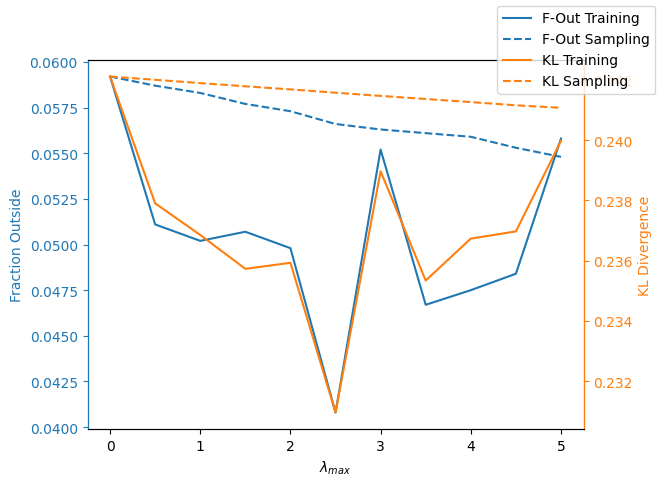

In [305]:
lams_training = [run["config"]["lambda_t"][0].cpu() for run in runs_training]
lams_sampling = [run["config"]["lambda_t"][0].cpu() for run in runs_sampling]
f_outs_training = [run["f_out"].cpu() for run in runs_training]
f_outs_sampling = [run["f_out"].cpu() for run in runs_sampling]
KLs_training = [run["KL"] for run in runs_training]
KLs_sampling = [run["KL"] for run in runs_sampling]

fig, ax1 = plt.subplots()

ax1.plot(lams_training, f_outs_training, color="tab:blue", label="F-Out Training")
ax1.plot(lams_sampling, f_outs_sampling, color="tab:blue", label="F-Out Sampling", linestyle="--")
ax1.set_ylabel("Fraction Outside", color="tab:blue")
ax1.set_xlabel(r"$\lambda_{max}$")
ax1.tick_params(axis='y', colors='tab:blue')

# Right y-axis
ax2 = ax1.twinx()
ax2.plot(lams_training, KLs_training, color="tab:orange", label="KL Training")
ax2.plot(lams_sampling, KLs_sampling, color="tab:orange", label="KL Sampling", linestyle="--")
ax2.set_ylabel("KL Divergence", color="tab:orange")
ax2.tick_params(axis='y', colors='tab:orange')

ax2.spines['left'].set_color('tab:blue')
ax2.spines['right'].set_color('tab:orange')


fig.legend()
epochs = runs_training[0]["config"]["epochs"]
plt.savefig(f"figures/epochs_{epochs}.pdf", bbox_inches="tight")

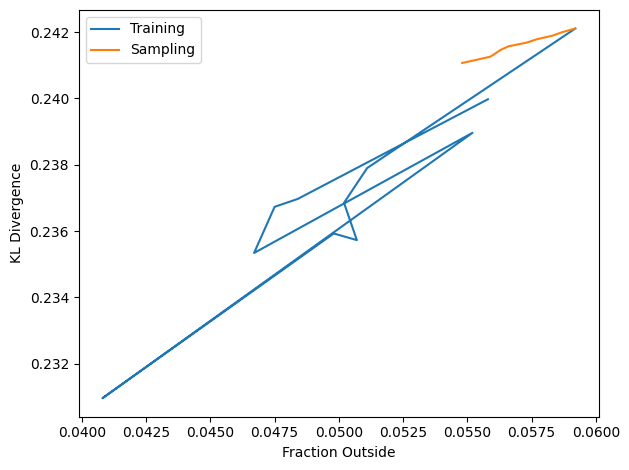

In [306]:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(f_outs_training, KLs_training, label="Training")
ax.plot(f_outs_sampling, KLs_sampling, label="Sampling")

ax.set_xlabel("Fraction Outside")
ax.set_ylabel("KL Divergence")

ax.legend()

plt.savefig("figures/KL_f_out.pdf", bbox_inches="tight")

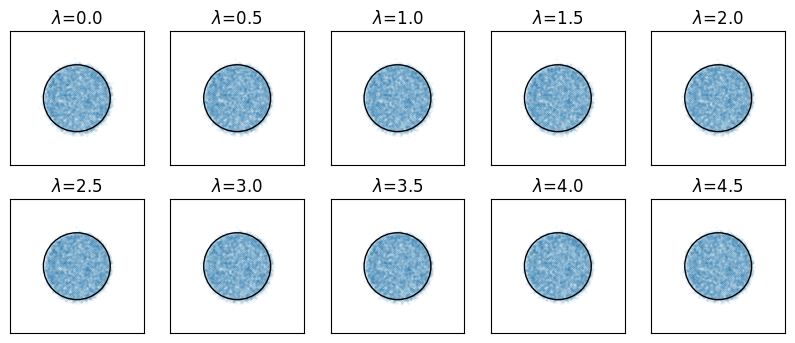

In [307]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for run, ax in zip(runs_training, axs.flatten()):
    config = run["config"]
    model = run["model"]

    samples = sample({**config, "mode": "baseline"}, model, y).cpu()

    points = samples - y.cpu()
    ax.scatter(points[:, 0], points[:, 1], marker="x", s=1, alpha=0.05)
    ax.add_patch(Circle((0, 0), radius=RADIUS, facecolor="none", edgecolor="black"))
    ax.set_aspect("equal")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(fr"$\lambda$={config["lambda_t"][0]:.1f}")

# Guidance Schedule

Potential schedules include
- Constant
- Linear
- Cosine
- Signal-to-Noise Ratio (SNR)

At $t=0$, $\text{SNR} \ne 1$ so $\lambda_{max}$ does not correspond to maximum value of $\lambda_t$

$$
\begin{align}
    \lambda_t &= \lambda_{max} \\
    \lambda_t &= \lambda_{max} \left( 1 - \frac{t}{T} \right) \\
    \lambda_t &= \lambda_{max}\ \cos^2{\left( \frac{t}{T} \frac{\pi}{2} \right)} \\
    \lambda_t &= \lambda_{max}\ \text{SNR}_t
\end{align}
$$

In [16]:
def run_schedule_experiment():
    rng = torch.Generator()
    rng.manual_seed(0)
    
    T = 100
    betas = torch.linspace(1e-4, 0.02, T).to(device)
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    lambdas = torch.linspace(0.0, 5.0, 21).to(device)

    schedules = {
        "const": torch.ones(T).to(device),
        "linear": torch.linspace(1.0, 0.0, T).to(device),
        "cosine": torch.cos(torch.linspace(0.0, torch.pi/2.0, T)).to(device)**2,
        # "snr": alphas_cumprod / (1 - alphas_cumprod),
    }

    fig, axs = plt.subplots(1, len(schedules), figsize=(12, 4), tight_layout=True)
    for ax, (key, value) in zip(axs, schedules.items()):
        ax.plot(value.cpu())
        ax.set_ylim(0, 1.1)

    plt.show()

    base_config = {
        "epochs": 1000,
        "batch_size": 512,
        "T": T,
        "alphas": alphas,
        "alphas_cumprod": alphas_cumprod,
        "betas": betas,
        "lambda_t": None
    }

    runs = {}

    for schedule_name, schedule in schedules.items():
        print(f"Train {schedule_name}")
        runs[schedule_name] = []
        for lam in tqdm(lambdas):
            lambda_t = schedule * lam
    
            config = {**base_config, "lambda_t": lambda_t}
            model = train(config)
            runs[schedule_name].append({"model": model, "config": config})

    return runs

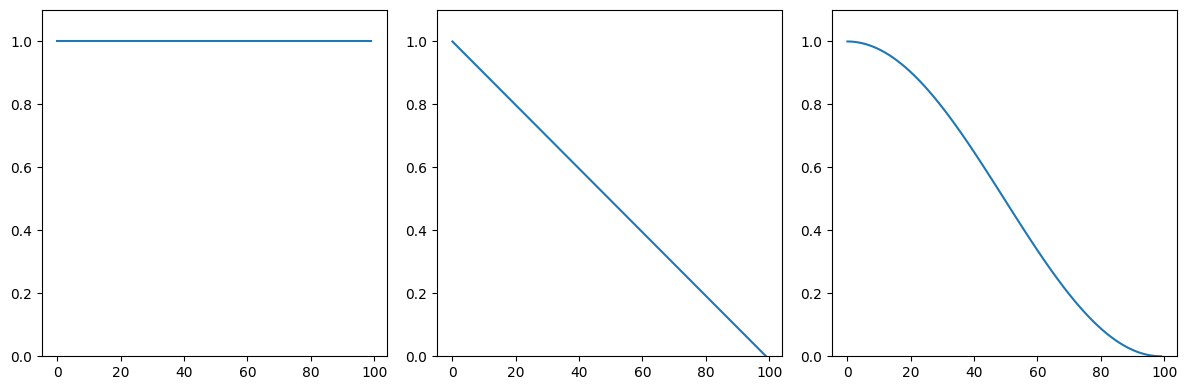

Train const


  0%|          | 0/21 [00:00<?, ?it/s]

Train linear


  0%|          | 0/21 [00:00<?, ?it/s]

Train cosine


  0%|          | 0/21 [00:00<?, ?it/s]

In [17]:
runs_schedule = run_schedule_experiment()

In [18]:
n_samples = 10_000
y = 2 * torch.rand((n_samples, 2)).to(device) - 1

kernel="tophat"
bandwidth="scott"

for run_name, runs in runs_schedule.items():
    print(f"Sampling {run_name.capitalize()}")
    for run in tqdm(runs):
        config = run["config"]
        model = run["model"]
    
        samples = sample({**config, "mode": "baseline"}, model, y)
    
        f_out = fraction_outside(samples, y)
        kde = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples.cpu() - y.cpu())
        KL = estimate_KL(kde)
    
        run.update({"KL": KL, "f_out": f_out})

Sampling Const


  0%|          | 0/21 [00:00<?, ?it/s]

Sampling Linear


  0%|          | 0/21 [00:00<?, ?it/s]

Sampling Cosine


  0%|          | 0/21 [00:00<?, ?it/s]

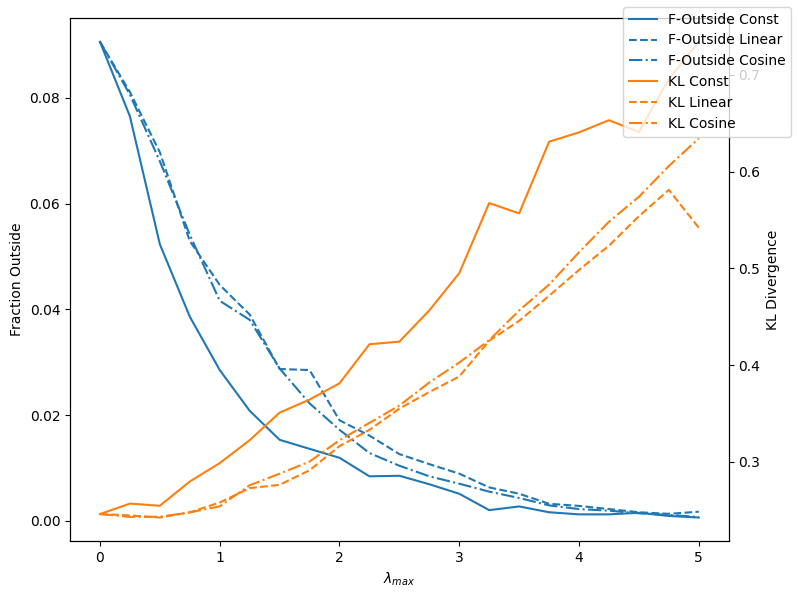

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 6), tight_layout=True)
ax2 = ax1.twinx()

linestyles = ["-", "--", "-."]

for (run_name, runs), linestyle in zip(runs_schedule.items(), linestyles):
    lams = [run["config"]["lambda_t"][0].cpu() for run in runs]

    # if run_name == "const":
    #     lams = [lam*2 for lam in lams]
    
    f_outs = [run["f_out"].cpu() for run in runs]
    KLs = [run["KL"] for run in runs]

    ax1.plot(lams, f_outs, color="tab:blue", label=f"F-Outside {run_name.capitalize()}", linestyle=linestyle)
    ax1.set_ylabel("Fraction Outside")
    ax1.set_xlabel(r"$\lambda_{max}$")
    
    ax2.plot(lams, KLs, color="tab:orange", label=f"KL {run_name.capitalize()}", linestyle=linestyle)
    ax2.set_ylabel("KL Divergence")
    
fig.legend()
plt.show()